## Robustness Testing of Topographical Correlation in Tumor Simulations

In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os

# Custom modules
from simulate_tumors import TumorCellSimulator, plot_cell_distribution
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from ecd_helperFunctions import *
from helperFunctions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Outline
1. Prepare data for TCM calculation
2. Generate perturbed datasets
3. Calculate TCM for each dataset
4. Calculate robustness metrics
5. Plot results

    `robustness_data = {'Sample': ['S1', 'S2', ...],
                'Baseline': [baseline_tcm1, baseline_tcm2, ...],
                'High Immune': ['high_immune_tcm1', 'high_immune_tcm2', ...],
                'High Tumor Density': ['high_ecd_tcm1', 'high_ecd_tcm2', ...]}`



In [2]:
# Load data
df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S5_L1.csv')

# Rename tumor_immune column to label
df = df.rename(columns={'tumor_immune': 'label', 'x_centroid': 'x', 'y_centroid': 'y'})

# List markers of interest
markers = ['tumor_cell', 'immune_cell']

# Keep only relevant columns
keep_cols = ['x', 'y']

# One hot encode cell types
df = create_cell_type_columns(df)

labels = {1: 'Tumor', 2: 'Immune'}

pc_df = generate_binary_pointcloud(df,
                                   markers=markers,
                                   keep_cols=keep_cols,
                                   labels=labels) 

# Check the pointcloud
pc_df.head()

,x,y,Celltype_asNumeric,Celltype
0,13626.9,2126.7,1,Tumor
1,13630.8,2134.8,1,Tumor
2,13636.0,2141.6,1,Tumor
3,13629.0,2145.8,1,Tumor
4,13621.0,2150.1,1,Tumor


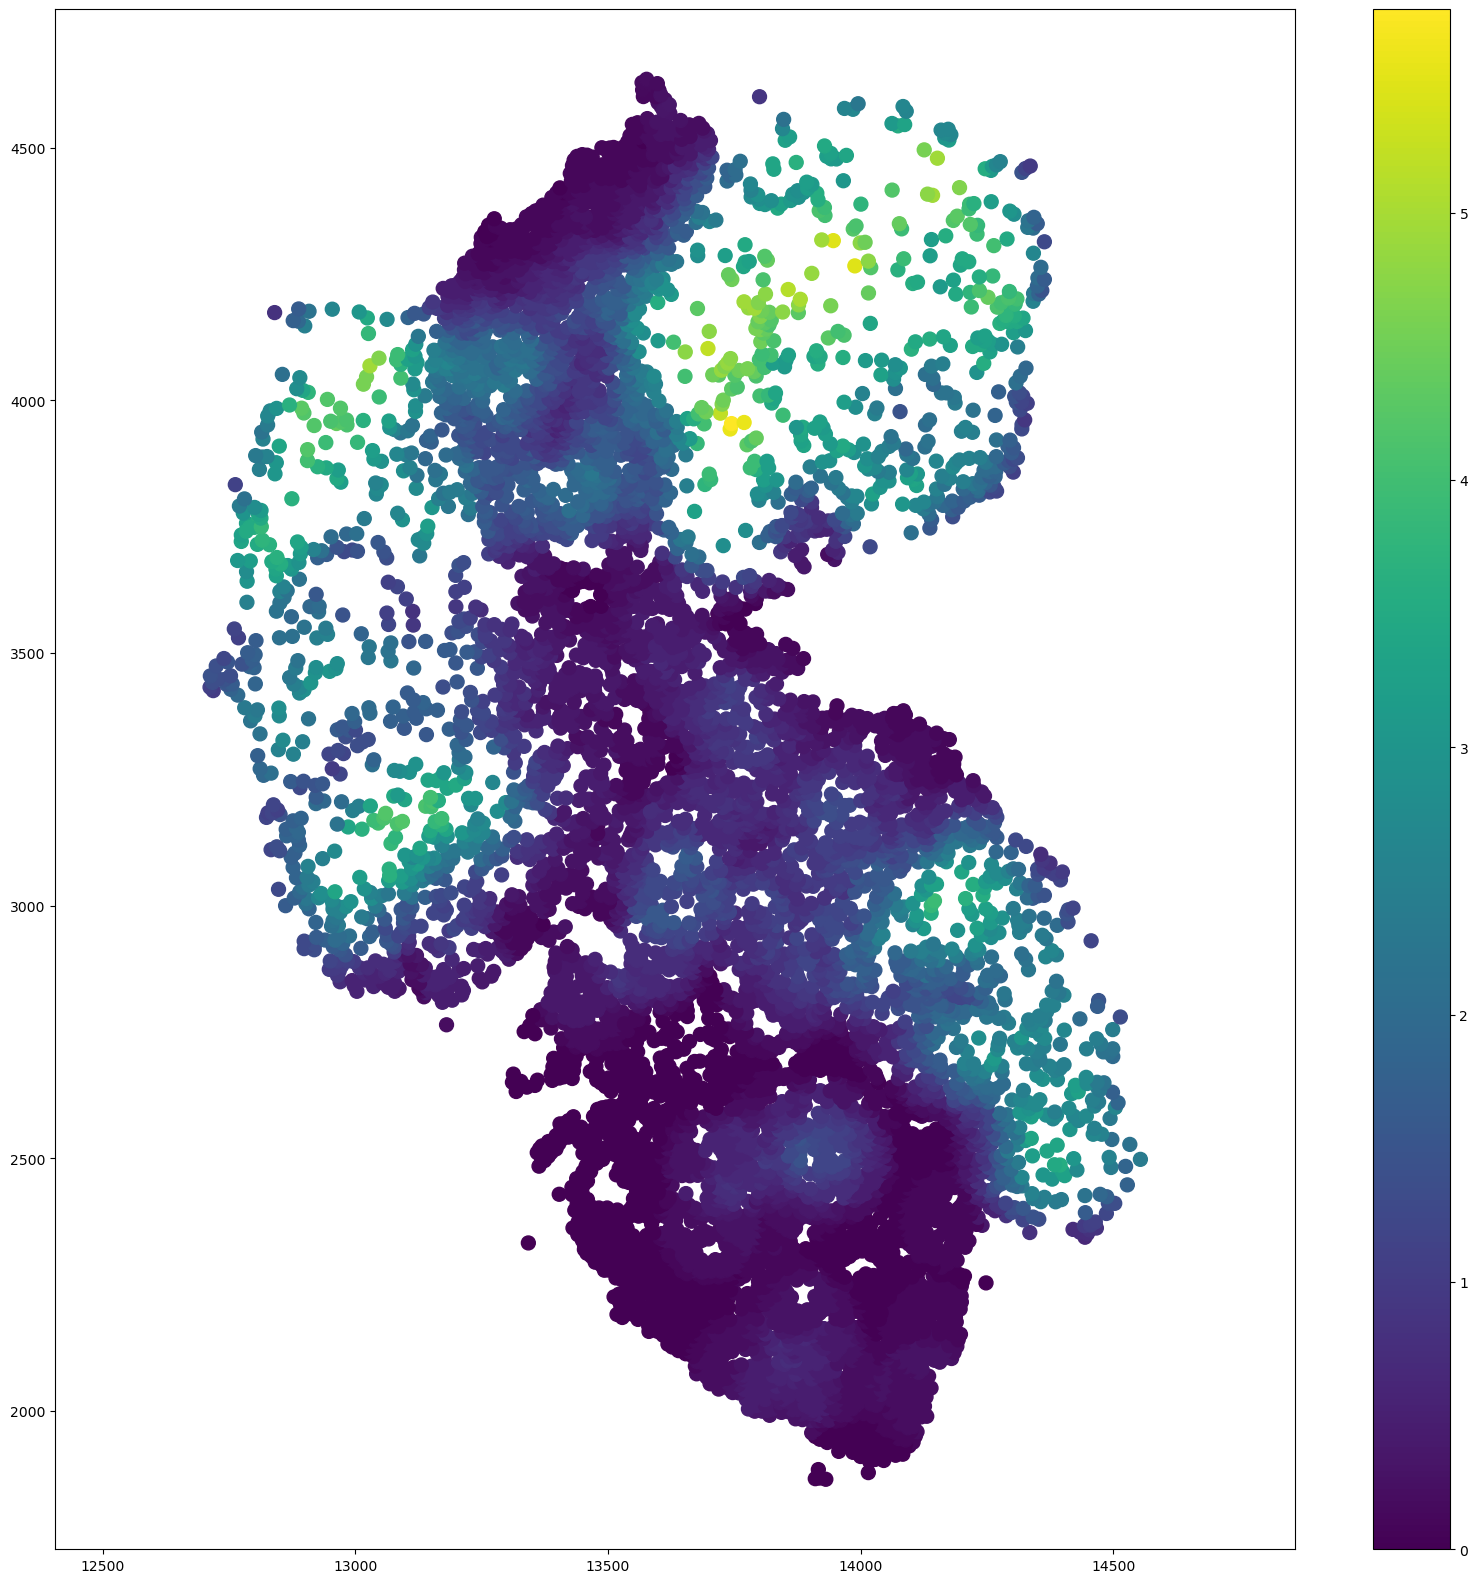

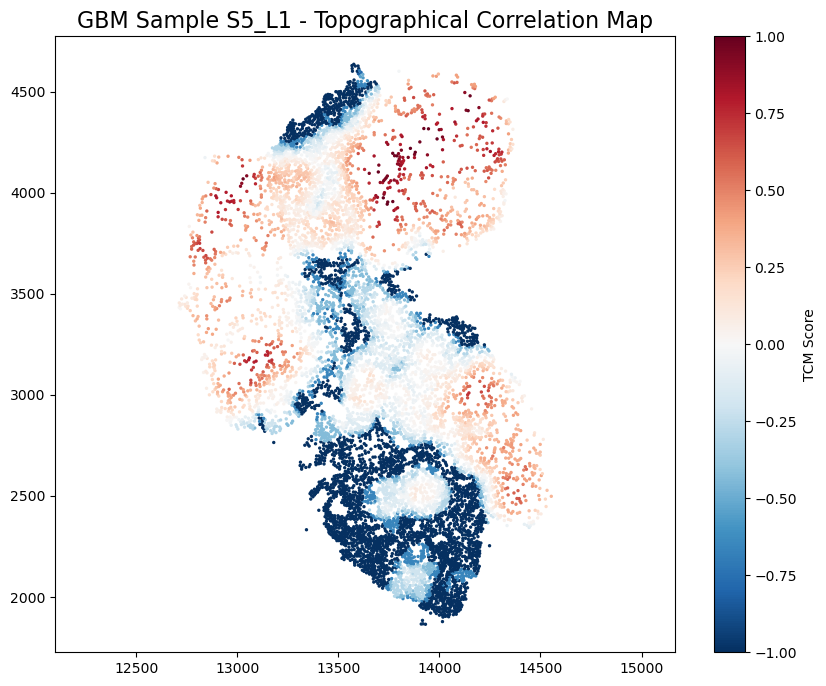

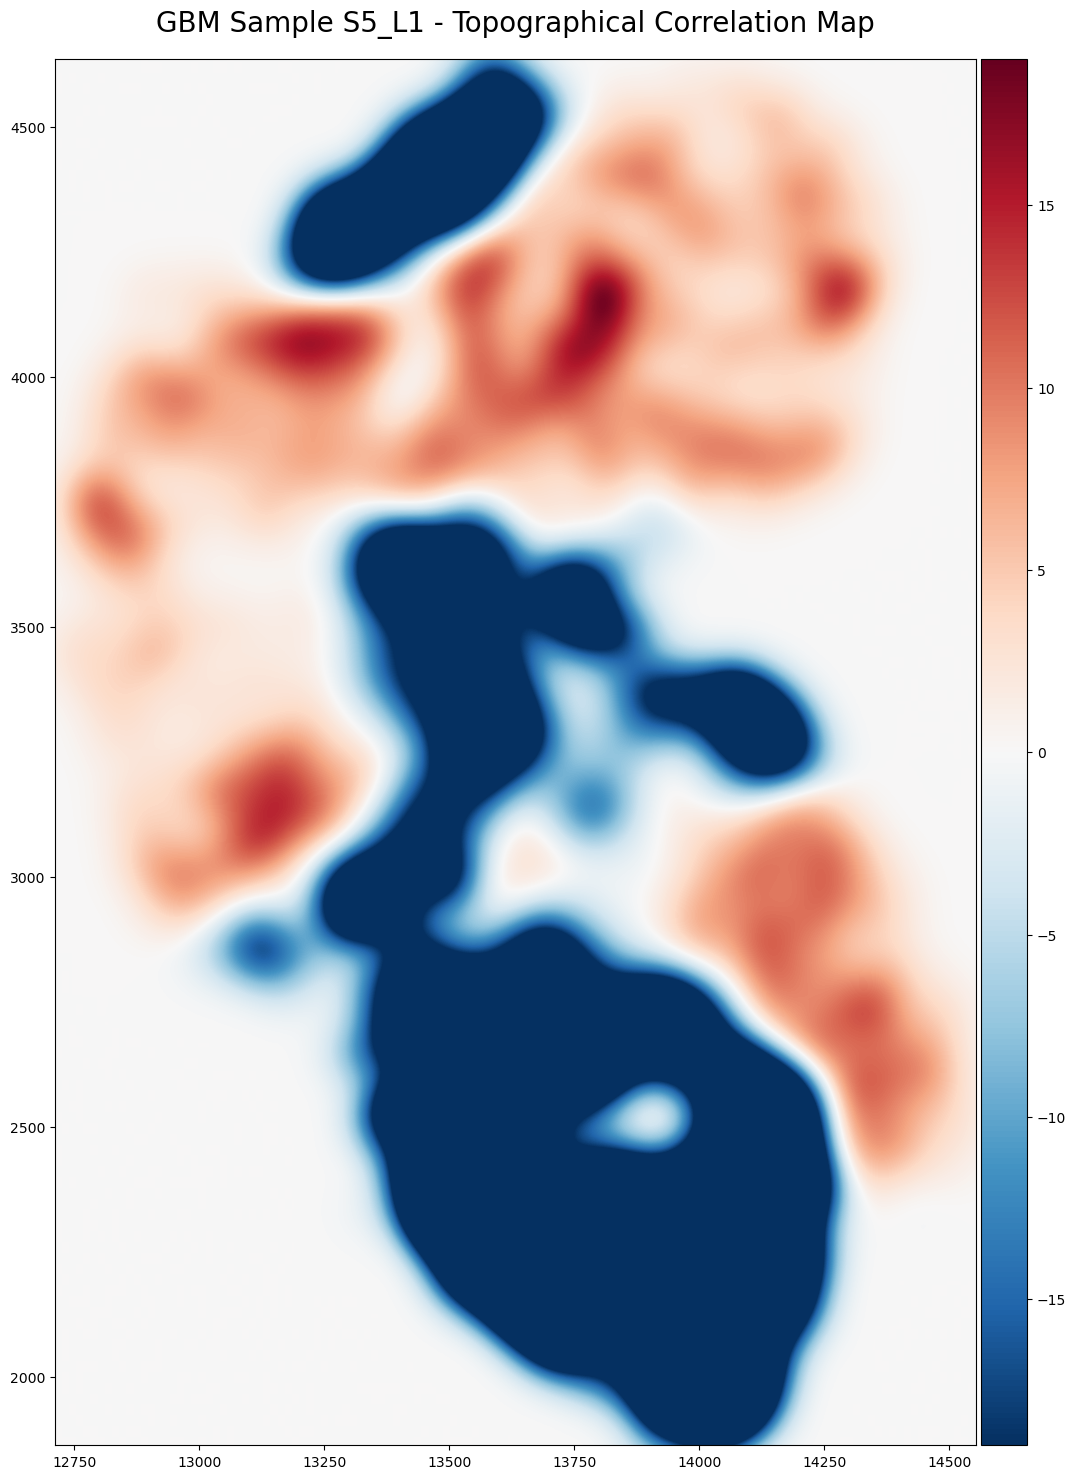

In [4]:
# Convert points to numpy array
points = np.asarray([pc_df['x'], pc_df['y']]).transpose()

# Convert pc_df['Celltype'] to a list
celltype_list = pc_df['Celltype'].tolist()

pc = generatePointCloud('tumor_immune', points)
pc.addLabels('Celltype', 'categorical', celltype_list, cmap='tab10')

# visualisePointCloud(pc, 'Celltype', markerSize=100)

# Define cell types of interest
typea = 'Tumor'
typeb = 'Immune'

# Calculate TCM
tcm = topographicalCorrelationMap(pc, 'Celltype', typea, 'Celltype', typeb, 
                                  radiusOfInterest=100, 
                                  maxCorrelationThreshold=5.0, 
                                  kernelRadius=150, 
                                  kernelSigma=50, 
                                  visualiseStages=True)

In [8]:
import pandas as pd
import seaborn as sns

results = pd.read_csv('/mnt/labshare/PROJECTS/SPATIAL_STATS/tcm_max_sens/max_sens_results.csv')
save_dir = '/mnt/labshare/PROJECTS/SPATIAL_STATS/figures'
#Create heatmap of results
plt.figure(figsize=(10,8))
results_df = pd.DataFrame(results).set_index('sample_name')
# Drop the unnamed index column
results_df = results_df.drop('Unnamed: 0', axis=1)

# Set custom min/max values for color scaling
vmin = results_df.min().min()  # Get minimum value
vmax = 0.5  # Get maximum value

# Create heatmap with custom scale
sns.heatmap(results_df, cmap='YlOrRd', annot=True, fmt='.3f',
            vmin=vmin, vmax=vmax,  # Set explicit min/max values
            center=(vmax-vmin)/2)  # Center the colormap

plt.xlabel('Simulation Type')
plt.ylabel('Sample')
plt.title('Infidelity Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'infidelity_heatmap.png'))
plt.close()

### Plot Infidelity

In [16]:
results = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/infidelity_results.csv')

save_dir = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/heatmaps'
#Create heatmap of results
plt.figure(figsize=(10,8))
results_df = pd.DataFrame(results).set_index('sample_name')
# Drop the unnamed index column
results_df = results_df.drop('Unnamed: 0', axis=1)

# Log transform the data
results_df = np.log10(results_df)

# Get actual min/max values from data for better color scaling
vmin = results_df.min().min()  # Get minimum value across all data
vmax = results_df.max().max()  # Get maximum value across all data

# Create heatmap with dynamic scale based on data range
sns.heatmap(results_df, cmap='YlOrRd', annot=True, fmt='.2f',
            vmin=vmin, vmax=vmax,  # Use data-driven min/max values
            center=(vmax+vmin)/2)  # Center the colormap on the data

plt.xlabel('Simulation Type')
plt.ylabel('Sample')
plt.title('Topographical Correlation Infidelity Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'tcm_infidelity_heatmap.png'))
plt.close()

In [15]:
results = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/max_sens_results.csv')

save_dir = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/tcm_results/heatmaps'
#Create heatmap of results
plt.figure(figsize=(10,8))
results_df = pd.DataFrame(results).set_index('sample')

# Log transform the data
results_df = np.log10(results_df)

# Get actual min/max values from data for better color scaling
vmin = results_df.min().min()  # Get minimum value across all data
vmax = results_df.max().max()  # Get maximum value across all data

# Create heatmap with dynamic scale based on data range
sns.heatmap(results_df, cmap='YlOrRd', annot=True, fmt='.2f',
            vmin=vmin, vmax=vmax,  # Use data-driven min/max values
            center=(vmax+vmin)/2)  # Center the colormap on the data

plt.xlabel('Simulation Type')
plt.ylabel('Sample')
plt.title('Topographical Correlation Maximum Sensitivity Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'tcm_max_sens_heatmap.png'))
plt.close() 